In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
root_path = os.path.abspath(os.path.join(os.getcwd(), "../.."))

if root_path not in sys.path:
    sys.path.append(root_path)

from src.optimizers.adam import AdamOptimizer
from src.models.quantile_regression import QuantileRegressionV1

In [ ]:
import numpy as np
import pandas as pd

train_path = "../../dataset/foodDeli_processed/train_processed.csv"

# Đọc file và loại bỏ luôn các dòng bị khuyết dữ liệu
train = pd.read_csv(train_path)

target_column = 'Time_taken' 
columns_to_drop = ['ID', target_column]

np.random.seed(42)
shuffled_indices = np.random.permutation(len(train))

# Chia tỷ lệ 80% Train - 20% Test
train_size = int(len(train) * 0.8)

train_indices = shuffled_indices[:train_size]
test_indices   = shuffled_indices[train_size:]

df_trainn = train.iloc[train_indices]
df_test  = train.iloc[test_indices]

# Trích xuất ma trận đặc trưng
X_train_raw = df_trainn.drop(columns=columns_to_drop, errors='ignore').values
y_train     = df_trainn[target_column].values

X_test_raw  = df_test.drop(columns=columns_to_drop, errors='ignore').values
y_test      = df_test[target_column].values

# Thêm cột hệ số chặn Bias
def add_bias_column(X):
    return np.hstack((np.ones((X.shape[0], 1)), X))

X_train = add_bias_column(X_train_raw)
X_test  = add_bias_column(X_test_raw)

print(f"Kích thước Train X: {X_train.shape} | Vector y: {y_train.shape}")
print(f"Kích thước Test X:  {X_test.shape}  | Vector y: {y_test.shape}")

Kích thước Train X: (30043, 23) | Vector y: (30043,)
Kích thước Test X:  (7511, 23)  | Vector y: (7511,)


In [12]:
adam_optimizer = AdamOptimizer(learning_rate=0.1, beta1=0.9, beta2=0.999, epsilon=1e-8)
model = QuantileRegressionV1(tau=0.9, optimizer=adam_optimizer)

print("Bắt đầu huấn luyện Batch Gradient Descent với Adam")
loss_history = model.fit(X_train, y_train, epochs=50000,  )
print("Thuật toán tối ưu hóa hoàn tất!")
loss_history = model.loss

Bắt đầu huấn luyện Batch Gradient Descent với Adam
Epoch 0/50000, Loss: 23.8476
Epoch 100/50000, Loss: 2.2117
Epoch 200/50000, Loss: 1.8654
Epoch 300/50000, Loss: 1.7302
Epoch 400/50000, Loss: 1.6408
Epoch 500/50000, Loss: 1.5769
Epoch 600/50000, Loss: 1.5261
Epoch 700/50000, Loss: 1.4838
Epoch 800/50000, Loss: 1.4485
Epoch 900/50000, Loss: 1.4182
Epoch 1000/50000, Loss: 1.3915
Epoch 1100/50000, Loss: 1.3676
Epoch 1200/50000, Loss: 1.3452
Epoch 1300/50000, Loss: 1.3243
Epoch 1400/50000, Loss: 1.3042
Epoch 1500/50000, Loss: 1.2845
Epoch 1600/50000, Loss: 1.2653
Epoch 1700/50000, Loss: 1.2468
Epoch 1800/50000, Loss: 1.2290
Epoch 1900/50000, Loss: 1.2117
Epoch 2000/50000, Loss: 1.1951
Epoch 2100/50000, Loss: 1.1797
Epoch 2200/50000, Loss: 1.1655
Epoch 2300/50000, Loss: 1.1528
Epoch 2400/50000, Loss: 1.1416
Epoch 2500/50000, Loss: 1.1317
Epoch 2600/50000, Loss: 1.1232
Epoch 2700/50000, Loss: 1.1160
Epoch 2800/50000, Loss: 1.1100
Epoch 2900/50000, Loss: 1.1052
Epoch 3000/50000, Loss: 1.1013

In [13]:
y_pred_test = model.predict(X_test)
test_loss = model.pinball_loss(y_test, y_pred_test)
print(f"Pinball Loss trên tập Test:       {test_loss:.4f}")

Pinball Loss trên tập Test:       1.0785


In [ ]:
weights_dir = "../../results/weights"
weights_path = os.path.join(weights_dir, "adam_theta1.npy")
loss_path  = os.path.join(weights_dir, "adam_loss1.npy")
# Sử dụng numpy để lưu trữ cấu trúc mảng
np.save(weights_path, model.theta)
np.save(loss_path, np.array(loss_history))

print(f"Trọng số tối ưu đã được lưu thành công! (theta):\n", model.theta)

Trọng số tối ưu đã được lưu thành công! (theta):
 [ 4.45102180e+01  2.39671054e+00 -2.19221969e+00  1.61015967e+00
 -7.36394183e-03  2.45821905e-02 -4.77436419e+00 -4.88528991e+00
 -5.19905443e+00 -4.75073814e+00  1.73059404e+00 -7.31892169e+00
 -1.83499223e+00 -1.94345996e-01  8.26949767e-02  1.71652418e-01
 -1.10019367e-01  1.62432221e-02 -6.08285404e+00 -6.17466580e+00
  7.83986374e+00  8.64816936e+00 -1.57088699e+00]


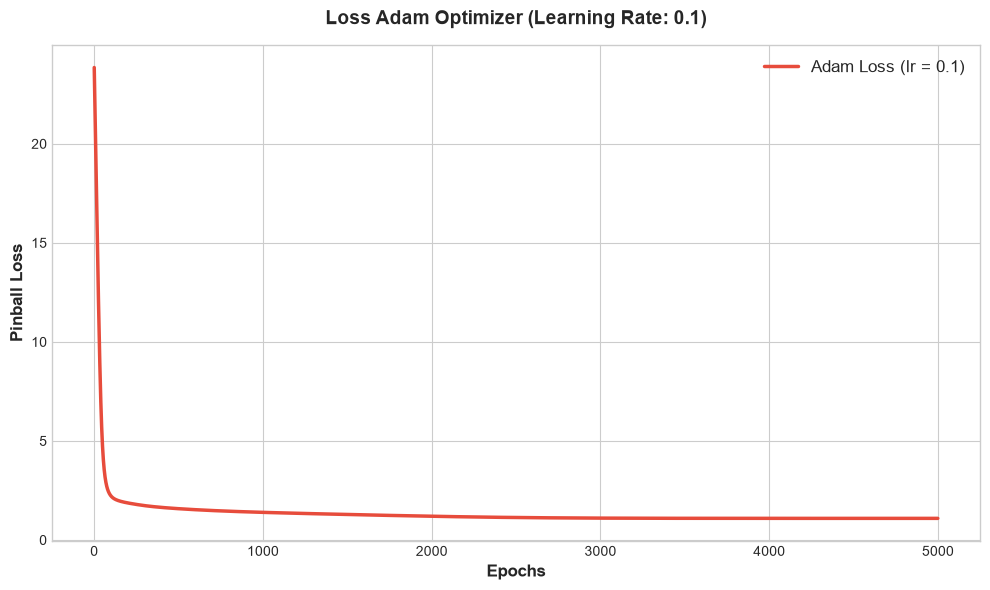

In [ ]:
learning_rate = 0.1
plots_dir = "../../results/plots/ADAM"
os.makedirs(plots_dir, exist_ok=True) 

plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid') 
plt.plot(loss_history[:5000], label=f'Adam Loss (lr = {learning_rate})', color='#e74c3c', linewidth=2.5)
plt.title(f'Loss Adam Optimizer (Learning Rate: {learning_rate})', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12, fontweight='bold')
plt.ylabel('Pinball Loss', fontsize=12, fontweight='bold')

plt.legend(fontsize=12, loc='upper right')
plt.tight_layout()

plot_filename = f"adam_loss_lr_{learning_rate}.png"
plot_path = os.path.join(plots_dir, plot_filename)
plt.savefig(plot_path, dpi=300)
plt.show()


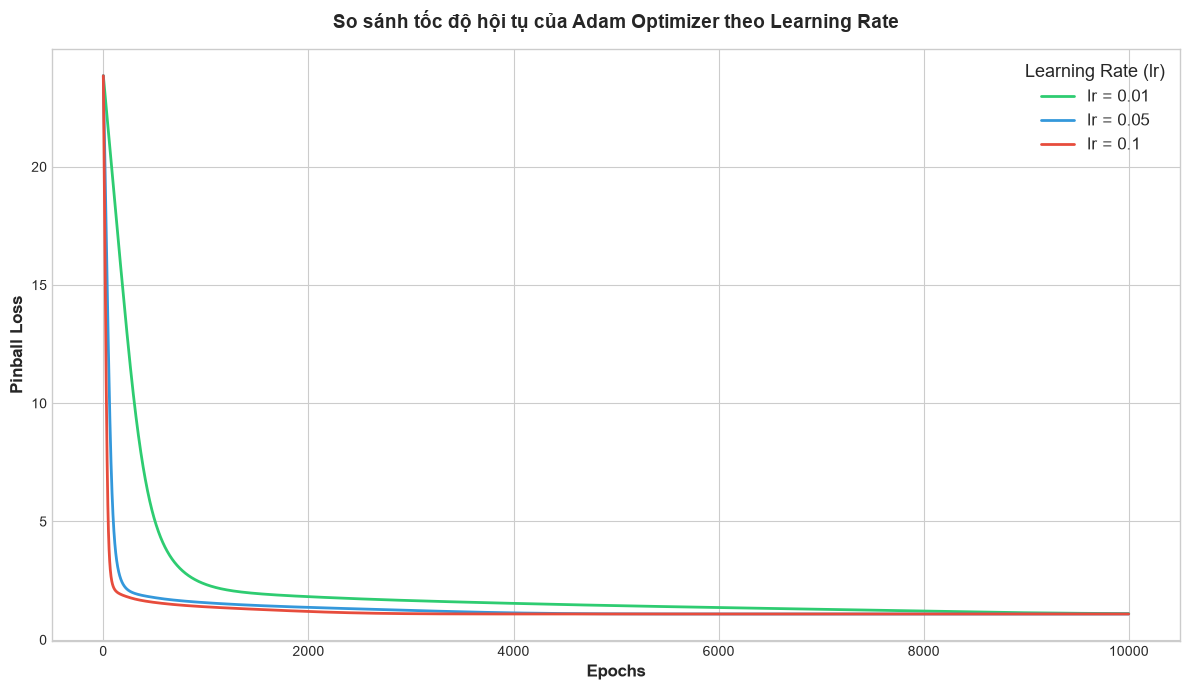

In [ ]:
path_001 = "../../results/weights/adam/adam_loss01.npy"
path_005 = "../../results/weights/adam/adam_loss05.npy"
path_01  = "../../results/weights/adam/adam_loss1.npy"

loss_001 = np.load(path_001)
loss_005 = np.load(path_005)
loss_01  = np.load(path_01)

plt.figure(figsize=(12, 7))
plt.style.use('seaborn-v0_8-whitegrid')
plt.plot(loss_001[:10000], label='lr = 0.01', color='#2ecc71', linewidth=2) 
plt.plot(loss_005[:10000], label='lr = 0.05', color='#3498db', linewidth=2) 
plt.plot(loss_01[:10000],  label='lr = 0.1', color='#e74c3c', linewidth=2)

plt.title('So sánh tốc độ hội tụ của Adam Optimizer theo Learning Rate', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12, fontweight='bold')
plt.ylabel('Pinball Loss', fontsize=12, fontweight='bold')
plt.legend(title="Learning Rate (lr)", fontsize=12, title_fontsize=13, loc='upper right')
plt.tight_layout()

plots_dir = "../../results/plots/ADAM"
os.makedirs(plots_dir, exist_ok=True)
save_path = os.path.join(plots_dir, "adam_loss_lr.png")
plt.savefig(save_path, dpi=300)
plt.show()